<a href="https://colab.research.google.com/github/Sadokbaklouti/flights-/blob/main/project1_fly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# réservations de vols
**« Un projet original de Guillaume Saint-Cirgue, extrait du Cahier de Vacances Data & IA 2026. »

In [1]:
import sqlite3

In [25]:
import pandas as pd


In [3]:
conn = sqlite3.connect(":memory:")
cursor = conn.cursor()
print("Connexion à la base établie !")

Connexion à la base établie !


In [4]:
cursor.execute('''
CREATE TABLE passengers (
    id          INTEGER PRIMARY KEY,
    first_name  TEXT NOT NULL,
    last_name   TEXT NOT NULL,
    email       TEXT UNIQUE,
    nationality TEXT
)

''')

In [5]:
passengers_data = [
    (1, 'Lucas',   'Moreau',   'lucas.moreau@email.fr',    'Française'),
    (2, 'Emma',    'Dubois',   'emma.dubois@email.fr',     'Française'),
    (3, 'Noah',    'Leroy',    'noah.leroy@email.fr',      'Française'),
    (4, 'Sofia',   'Rossi',    'sofia.rossi@email.it',     'Italienne'),
    (5, 'Liam',    'Smith',    'liam.smith@email.uk',      'Britannique'),
    (6, 'Mia',     'Müller',   'mia.muller@email.de',      'Allemande'),
    (7, 'Hugo',    'Bernard',  'hugo.bernard@email.fr',    'Française'),
    (8, 'Camille', 'Thomas',   'camille.thomas@email.fr',  'Française'),
    (9, 'Alice',   'Martin',   'alice.martin@email.fr',    'Française'),
    (10,'Carlos',  'Garcia',   'carlos.garcia@email.es',   'Espagnole'),
    (11,'Jade',    'Petit',    'jade.petit@email.fr',      'Française'),
    (12,'Omar',    'Hassan',   'omar.hassan@email.ma',     'Marocaine'),
    (13,'Elena',   'Popescu',  'elena.popescu@email.ro',   'Roumaine'),
    (14,'Antoine', 'Garnier',  'antoine.garnier@email.fr', 'Française'),
    (15,'Yako',    'Tanaka',   'yuki.tanaka@email.jp',     'Japonaise'),
]

In [6]:
cursor.executemany("INSERT INTO passengers VALUES (?,?,?,?,?)", passengers_data)
conn.commit()


In [7]:
cursor.execute("SELECT COUNT(*) FROM passengers")
count = cursor.fetchone()[0]

assert count == 15, f"La table passengers devrait contenir 15 passagers, elle en a {count}"
print(f"Table passengers créée et remplie avec {count} passagers !")

Table passengers créée et remplie avec 15 passagers !


In [12]:
#create table flights
cursor.execute('''
CREATE TABLE flights(
  id	INTEGER	PRIMARY KEY,
  flight_number	TEXT	NOT NULL,
  origin	TEXT	NOT NULL,
  destination	TEXT	NOT NULL,
  departure_time	TEXT	NOT NULL,
  arrival_time	TEXT	NOT NULL,
  aircraft	TEXT	,
  capacity	INTEGER,
  price_eur	REAL

)

''')

In [13]:
flights_data = [
    (1,  'AF1234', 'Nice',      'Paris CDG',    '2026-07-01 07:00', '2026-07-01 08:30', 'Airbus A320', 180, 89.0),
    (2,  'AF1235', 'Paris CDG', 'Nice',          '2026-07-01 19:00', '2026-07-01 20:30', 'Airbus A320', 180, 95.0),
    (3,  'EZ4501', 'Nice',      'Londres',       '2026-07-02 06:30', '2026-07-02 08:15', 'Airbus A319', 156, 120.0),
    (4,  'EZ4502', 'Nice',      'Amsterdam',     '2026-07-02 09:00', '2026-07-02 11:30', 'Airbus A319', 156, 135.0),
    (5,  'VY6010', 'Nice',      'Barcelone',     '2026-07-03 11:00', '2026-07-03 12:45', 'Boeing 737',  189, 78.0),
    (6,  'AF5501', 'Nice',      'New York JFK',  '2026-07-04 13:00', '2026-07-04 22:30', 'Boeing 777',  350, 650.0),
    (7,  'LH2201', 'Nice',      'Francfort',     '2026-07-05 08:00', '2026-07-05 09:45', 'Airbus A320', 180, 112.0),
    (8,  'IB3301', 'Nice',      'Madrid',        '2026-07-05 14:00', '2026-07-05 16:00', 'Boeing 737',  189, 99.0),
    (9,  'AF1236', 'Nice',      'Paris CDG',     '2026-07-06 18:00', '2026-07-06 19:30', 'Airbus A320', 180, 105.0),
    (10, 'U24401', 'Nice',      'Athènes',       '2026-07-07 10:00', '2026-07-07 13:30', 'Boeing 737',  189, 145.0),
    (11, 'FR7701', 'Nice',      'Dublin',        '2026-07-08 07:30', '2026-07-08 10:00', 'Boeing 737',  189, 89.0),
    (12, 'AF1237', 'Paris CDG', 'Nice',          '2026-07-08 20:00', '2026-07-08 21:30', 'Airbus A321', 220, 88.0),
    (13, 'EZ4503', 'Nice',      'Berlin',        '2026-07-09 12:00', '2026-07-09 14:15', 'Airbus A319', 156, 118.0),
    (14, 'AF5502', 'Nice',      'New York JFK',  '2026-07-10 13:00', '2026-07-10 22:30', 'Boeing 777',  350, 680.0),
    (15, 'TK8801', 'Nice',      'Istanbul',      '2026-07-11 09:00', '2026-07-11 12:30', 'Boeing 737',  189, 160.0),
]

In [15]:
cursor.executemany("INSERT INTO flights VALUES (?,?,?,?,?,?,?,?,?)", flights_data)
conn.commit()




IntegrityError: UNIQUE constraint failed: flights.id

In [17]:
cursor.execute("PRAGMA table_info(flights)")
columns = cursor.fetchall()
schema = {col[1]: col[2] for col in columns}
expected_schema = {
    'id': 'INTEGER', 'flight_number': 'TEXT', 'origin': 'TEXT', 'destination': 'TEXT',
    'departure_time': 'TEXT', 'arrival_time': 'TEXT', 'aircraft': 'TEXT',
    'capacity': 'INTEGER', 'price_eur': 'REAL',
}
assert schema == expected_schema, f"Le schéma ne correspond pas. Attendu : {expected_schema}, obtenu : {schema}"

not_null_columns = {col[1] for col in columns if col[3] == 1}
expected_not_null = {'flight_number', 'origin', 'destination', 'departure_time', 'arrival_time'}
assert not_null_columns == expected_not_null, \
    f"Les colonnes NOT NULL attendues sont {expected_not_null}, tu as : {not_null_columns}"

cursor.execute("SELECT COUNT(*) FROM flights")
count = cursor.fetchone()[0]
assert count == 15, f"La table flights devrait contenir 15 vols, elle en a {count}"
print(f"Table flights créée et remplie avec {count} vols, exercice validé !")



Table flights créée et remplie avec 15 vols, exercice validé !


In [20]:
cursor.execute('''
CREATE TABLE bookings(
 id	INTEGER	PRIMARY KEY,
passenger_id	INTEGER	REFERENCES passengers(id),
flight_id	INTEGER	REFERENCES flights(id),
booking_date	TEXT	,
seat_class	TEXT	CHECK(seat_class IN ('economy', 'business', 'first')),
seat_number	TEXT	,
status	TEXT	CHECK(status IN ('confirmed', 'cancelled', 'pending'))

)
''')

In [21]:
bookings_data = [
    (1,  1,  1,  '2026-06-01', 'economy',  '14A', 'confirmed'),
    (2,  2,  1,  '2026-06-02', 'business', '2C',  'confirmed'),
    (4,  4,  5,  '2026-06-05', 'economy',  '18C', 'confirmed'),
    (5,  5,  3,  '2026-06-06', 'business', '1A',  'confirmed'),
    (6,  6,  7,  '2026-06-07', 'economy',  '31D', 'confirmed'),
    (7,  7,  6,  '2026-06-08', 'first',    '1A',  'confirmed'),
    (8,  8,  6,  '2026-06-09', 'business', '3B',  'confirmed'),
    (9,  9,  9,  '2026-06-10', 'economy',  '25A', 'confirmed'),
    (10, 10, 5,  '2026-06-11', 'economy',  '17B', 'cancelled'),
    (11, 11, 10, '2026-06-12', 'economy',  '8C',  'confirmed'),
    (12, 12, 15, '2026-06-13', 'economy',  '11A', 'confirmed'),
    (13, 13, 4,  '2026-06-14', 'economy',  '29B', 'pending'),
    (14, 14, 2,  '2026-06-15', 'business', '4A',  'confirmed'),
    (15, 15, 6,  '2026-06-16', 'first',    '2A',  'confirmed'),
    (16, 1,  9,  '2026-06-17', 'economy',  '33C', 'confirmed'),
    (17, 2,  10, '2026-06-18', 'economy',  '15A', 'cancelled'),
    (18, 5,  6,  '2026-06-19', 'business', '5B',  'confirmed'),
    (19, 7,  14, '2026-06-20', 'first',    '1B',  'confirmed'),
    (20, 9,  11, '2026-06-21', 'economy',  '22D', 'confirmed'),
]

In [22]:
cursor.executemany("INSERT INTO bookings VALUES (?,?,?,?,?,?,?)", bookings_data)
conn.commit()

In [23]:
cursor.execute("PRAGMA table_info(bookings)")
schema = {col[1]: col[2] for col in cursor.fetchall()}
expected_schema = {
    'id': 'INTEGER', 'passenger_id': 'INTEGER', 'flight_id': 'INTEGER',
    'booking_date': 'TEXT', 'seat_class': 'TEXT', 'seat_number': 'TEXT', 'status': 'TEXT',
}
assert schema == expected_schema, f"Le schéma ne correspond pas. Attendu : {expected_schema}, obtenu : {schema}"

try:
    cursor.execute("INSERT INTO bookings VALUES (999, 1, 1, '2026-06-30', 'premium', '1A', 'confirmed')")
    raise AssertionError("La contrainte CHECK sur seat_class ne fonctionne pas : 'premium' a été accepté")
except sqlite3.IntegrityError:
    pass

cursor.execute("SELECT COUNT(*) FROM bookings")
count = cursor.fetchone()[0]
assert count == 19, f"La table bookings devrait contenir 19 réservations, elle en a {count}"

print("Base de données complète, exercice validé !")
print(f"  {len(passengers_data)} passagers")
print(f"  {len(flights_data)} vols")
print(f"  {len(bookings_data)} réservations")

Base de données complète, exercice validé !
  15 passagers
  15 vols
  19 réservations


In [27]:
#creat a function
def query(sql):
    '''Execute a SQL query and return the result as a pandas DataFrame.'''
    return pd.read_sql_query(sql, conn)

print("=== PASSENGERS ===")
display(query("SELECT * FROM passengers LIMIT 5"))
print("=== FLIGHTS ===")
display(query("SELECT * FROM flights LIMIT 5"))
print("=== BOOKINGS ===")
display(query("SELECT * FROM bookings LIMIT 5"))

=== PASSENGERS ===


,id,first_name,last_name,email,nationality
0,1,Lucas,Moreau,lucas.moreau@email.fr,Française
1,2,Emma,Dubois,emma.dubois@email.fr,Française
2,3,Noah,Leroy,noah.leroy@email.fr,Française
3,4,Sofia,Rossi,sofia.rossi@email.it,Italienne
4,5,Liam,Smith,liam.smith@email.uk,Britannique


=== FLIGHTS ===


,id,flight_number,origin,destination,departure_time,arrival_time,aircraft,capacity,price_eur
0,1,AF1234,Nice,Paris CDG,2026-07-01 07:00,2026-07-01 08:30,Airbus A320,180,89.0
1,2,AF1235,Paris CDG,Nice,2026-07-01 19:00,2026-07-01 20:30,Airbus A320,180,95.0
2,3,EZ4501,Nice,Londres,2026-07-02 06:30,2026-07-02 08:15,Airbus A319,156,120.0
3,4,EZ4502,Nice,Amsterdam,2026-07-02 09:00,2026-07-02 11:30,Airbus A319,156,135.0
4,5,VY6010,Nice,Barcelone,2026-07-03 11:00,2026-07-03 12:45,Boeing 737,189,78.0


=== BOOKINGS ===


,id,passenger_id,flight_id,booking_date,seat_class,seat_number,status
0,1,1,1,2026-06-01,economy,14A,confirmed
1,2,2,1,2026-06-02,business,2C,confirmed
2,4,4,5,2026-06-05,economy,18C,confirmed
3,5,5,3,2026-06-06,business,1A,confirmed
4,6,6,7,2026-06-07,economy,31D,confirmed


# Part 2

In [28]:
result = query("""
SELECT flight_number, destination, departure_time, price_eur
FROM flights
WHERE origin = 'Nice'
ORDER BY departure_time
""")

display(result)

assert len(result) == 13, f"Tu devrais avoir 13 vols au départ de Nice, tu en as {len(result)}"
assert list(result.columns) == ['flight_number', 'destination', 'departure_time', 'price_eur'], \
    "Vérifie les colonnes sélectionnées"
print("Exercice validé !")

,flight_number,destination,departure_time,price_eur
0,AF1234,Paris CDG,2026-07-01 07:00,89.0
1,EZ4501,Londres,2026-07-02 06:30,120.0
2,EZ4502,Amsterdam,2026-07-02 09:00,135.0
3,VY6010,Barcelone,2026-07-03 11:00,78.0
4,AF5501,New York JFK,2026-07-04 13:00,650.0
5,LH2201,Francfort,2026-07-05 08:00,112.0
6,IB3301,Madrid,2026-07-05 14:00,99.0
7,AF1236,Paris CDG,2026-07-06 18:00,105.0
8,U24401,Athènes,2026-07-07 10:00,145.0
9,FR7701,Dublin,2026-07-08 07:30,89.0


Exercice validé !


In [29]:
result = query("""
SELECT  flight_number, destination, price_eur
FROM flights
WHERE price_eur < 100
ORDER BY price_eur
""")
display(result)

assert len(result) == 6, f"Tu devrais avoir 6 vols sous 100 euros, tu en as {len(result)}"
assert result['price_eur'].is_monotonic_increasing, "Les résultats doivent être triés par prix croissant"
print("Exercice validé !")

,flight_number,destination,price_eur
0,VY6010,Barcelone,78.0
1,AF1237,Nice,88.0
2,AF1234,Paris CDG,89.0
3,FR7701,Dublin,89.0
4,AF1235,Nice,95.0
5,IB3301,Madrid,99.0


Exercice validé !


In [30]:
#3: Rechercher des noms de passager

result = query("""
SELECT first_name, last_name
FROM passengers
WHERE last_name LIKE 'Tanaka'
""")
display(result)

assert len(result) == 1
assert result.iloc[0]['first_name'] == 'Yako'
print("Exercice validé !")

,first_name,last_name
0,Yako,Tanaka


Exercice validé !


# Partie 3

In [32]:
#Étape 1 : l'état des réservations
result = query("""
SELECT status, COUNT(*) AS count
FROM bookings
GROUP BY status
""")
display(result)

assert len(result) == 3, "Il doit y avoir 3 statuts distincts"
confirmed_count = result[result['status'] == 'confirmed']['count'].values[0]
assert confirmed_count == 16, f"Il devrait y avoir 16 réservations confirmées, tu en as {confirmed_count}"
print("Exercice validé !")

,status,count
0,cancelled,2
1,confirmed,16
2,pending,1


Exercice validé !


### Étape 2 : Chiffre d'affaires total pour les réservations confirmées

In [39]:
#Étape 2 : le chiffre d'affaires par destination
result = query("""
SELECT
    f.destination,
    SUM(f.price_eur) AS total_revenue,
    COUNT(b.id) AS nb_bookings
FROM
    flights f
JOIN
    bookings b ON f.id = b.flight_id
WHERE
    b.status = 'confirmed'
GROUP BY
    f.destination
ORDER BY
    total_revenue DESC
""")
display(result)

assert 'destination' in result.columns
assert 'total_revenue' in result.columns
assert 'nb_bookings' in result.columns
assert result['total_revenue'].is_monotonic_decreasing, "Trie par CA décroissant"
top_dest = result.iloc[0]['destination']
assert top_dest == 'New York JFK', f"La destination avec le plus de CA (confirmé) devrait être New York JFK, pas {top_dest}"
assert result.iloc[0]['total_revenue'] == 3280.0, "Le CA pour New York JFK (confirmé) est incorrect"
assert result.iloc[0]['nb_bookings'] == 5, "Le nombre de réservations pour New York JFK (confirmé) est incorrect"
assert len(result) == 9, "Il devrait y avoir 9 destinations avec des réservations confirmées"
print("Exercice validé !")

,destination,total_revenue,nb_bookings
0,New York JFK,3280.0,5
1,Paris CDG,388.0,4
2,Istanbul,160.0,1
3,Athènes,145.0,1
4,Londres,120.0,1
5,Francfort,112.0,1
6,Nice,95.0,1
7,Dublin,89.0,1
8,Barcelone,78.0,1


Exercice validé !


# Étape 3 : ne garder que la demande récurrente

In [41]:
result = query("""
SELECT
    f.destination,
    SUM(f.price_eur) AS total_revenue,
    COUNT(b.id) AS nb_bookings
FROM
    flights f
JOIN
    bookings b ON f.id = b.flight_id
WHERE
    b.status = 'confirmed'
GROUP BY
    f.destination
HAVING
    nb_bookings > 1
ORDER BY
    total_revenue DESC
""")
display(result)

assert all(result['nb_bookings'] > 1), "Toutes les destinations affichées doivent avoir plus d'une réservation"
print("Exercice validé !")

,destination,total_revenue,nb_bookings
0,New York JFK,3280.0,5
1,Paris CDG,388.0,4


Exercice validé !


# Étape 4 : zoom sur la clientèle de la destination en tête

In [46]:
result = query("""
select p.first_name , p.last_name, b.seat_class, b.seat_number
from passengers p
JOIN
    bookings b ON p.id = b.passenger_id
    JOIN
    flights f ON b.flight_id = f.id
WHERE
    f.destination = 'New York JFK' AND b.status = 'confirmed'
""")
display(result)

assert len(result) == 5, f"Il devrait y avoir 5 réservations confirmées pour New York JFK, tu en as {len(result)}"
names = set(result['last_name'].values)
assert names == {'Bernard', 'Thomas', 'Tanaka', 'Smith'}, f"Les passagers uniques attendus sont Bernard, Thomas, Tanaka, Smith. Tu as : {names}"
print("Exercice validé !")

,first_name,last_name,seat_class,seat_number
0,Hugo,Bernard,first,1A
1,Camille,Thomas,business,3B
2,Yako,Tanaka,first,2A
3,Liam,Smith,business,5B
4,Hugo,Bernard,first,1B


Exercice validé !


# Étape 5 : les clients à démarcher

In [47]:
result = query("""
select p.first_name , p.last_name, b.seat_class, b.seat_number
from passengers p
JOIN
    bookings b ON p.id = b.passenger_id

where b.status = 'pending'
""")
display(result)

assert len(result) == 1, f"Il y a 1 passagers sans réservation, tu en as {len(result)}"
print("Exercice validé !")

,first_name,last_name,seat_class,seat_number
0,Elena,Popescu,economy,29B


Exercice validé !


### Étape 6 : les passagers sans aucune réservation

In [49]:
result = query("""
SELECT p.first_name, p.last_name
FROM passengers p
LEFT JOIN bookings b ON p.id = b.passenger_id
WHERE b.id IS NULL
""")
display(result)

assert len(result) == 1, f"Il y a 1 passagers sans réservation, tu en as {len(result)}"
print("Exercice validé !")

,first_name,last_name
0,Noah,Leroy


Exercice validé !


# Étape 6 : le positionnement prix

In [50]:
result = query("""
select flight_number, destination, price_eur
from flights
where price_eur > (select avg(price_eur) from flights)
order by price_eur desc
""")
display(result)

avg_price = pd.read_sql_query("SELECT AVG(price_eur) as avg FROM flights", conn)['avg'].values[0]
assert all(result['price_eur'] > avg_price), f"Tous les vols doivent être au-dessus de la moyenne ({avg_price:.2f} euros)"
print(f"Prix moyen : {avg_price:.2f} euros")
print("Exercice validé !")

,flight_number,destination,price_eur
0,AF5502,New York JFK,680.0
1,AF5501,New York JFK,650.0


Prix moyen : 184.20 euros
Exercice validé !


# Étape 7 : les ambassadeurs du nouveau vol

In [52]:
result = query("""
SELECT p.first_name, p.last_name, COUNT(b.id) AS nb_bookings
FROM passengers p
JOIN bookings b ON p.id = b.passenger_id
GROUP BY p.id, p.first_name, p.last_name
HAVING nb_bookings >= 2
ORDER BY nb_bookings DESC
""")
display(result)

assert len(result) == 5, f"Il y a 5 passagers avec 2+ réservations, tu en as {len(result)}"
assert all(result['nb_bookings'] >= 2)
print("Exercice validé !")

,first_name,last_name,nb_bookings
0,Lucas,Moreau,2
1,Emma,Dubois,2
2,Liam,Smith,2
3,Hugo,Bernard,2
4,Alice,Martin,2


Exercice validé !


# Conclusion : La réponse au directeur

,destination,total_revenue,nb_bookings
0,New York JFK,3280.0,5
1,Paris CDG,388.0,4


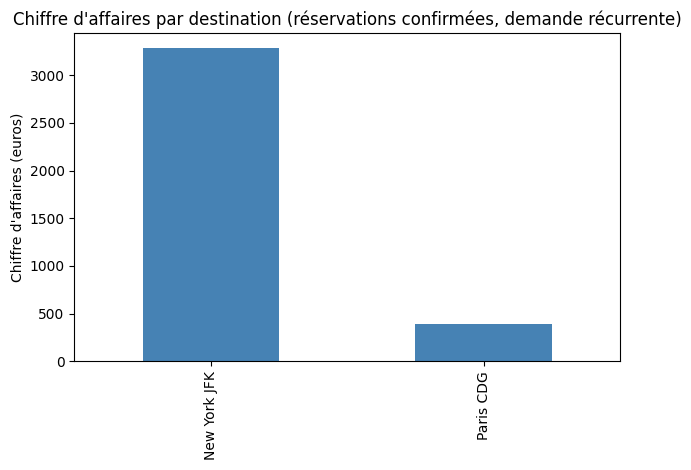

In [53]:
import matplotlib.pyplot as plt

result = query("""

SELECT
    f.destination,
    SUM(f.price_eur) AS total_revenue,
    COUNT(b.id) AS nb_bookings
FROM
    flights f
JOIN
    bookings b ON f.id = b.flight_id
WHERE
    b.status = 'confirmed'
GROUP BY
    f.destination
HAVING
    nb_bookings > 1
ORDER BY
    total_revenue DESC

""")
display(result)

assert result.iloc[0]['destination'] == 'New York JFK', \
    f"La destination en tête devrait être New York JFK, tu as {result.iloc[0]['destination']}"

result.plot(kind='bar', x='destination', y='total_revenue', legend=False, color='steelblue')
plt.title("Chiffre d'affaires par destination (réservations confirmées, demande récurrente)")
plt.ylabel("Chiffre d'affaires (euros)")
plt.xlabel("")
plt.tight_layout()
plt.show()

** Recommandation : ** renforcer la ligne Nice - New York JFK. C'est de loin la destination qui génère le plus de chiffre d'affaires, avec une demande récurrente **